# Suicide Ideation Tweet Classification Using Natural Language Processing

## Project Overview

This project uses Natural Language Processing (NLP) and machine learning to classify tweets into two categories:

- **Not Suicide Post**
- **Potential Suicide Post**

The goal is to develop a text classification model that can identify tweets that may contain indicators of suicide ideation based on patterns learned from a labeled dataset.

This project demonstrates the following data science skills:

- Data loading and exploration
- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Natural Language Processing (NLP)
- TF-IDF text vectorization
- Machine learning classification
- Logistic Regression
- Model evaluation
- Precision, recall, and F1-score analysis
- Confusion matrix analysis
- Error analysis
- Prediction on new text

> **Important Note:** I do not plan for this project to diagnose individuals or determine whether a person is suicidal. Predictions should be treated as potential risk flags that would require appropriate human review.

## 1. Import Required Libraries

The following libraries will be used for data manipulation, visualization, natural language processing, machine learning, and model evaluation.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 2. Load the Dataset

The dataset contains two columns:

- `Tweet`: The text of the tweet
- `Suicide`: The classification assigned to the tweet

The target variable contains two classes:

- `Not Suicide post`
- `Potential Suicide post`

In [2]:
# Load the dataset
df = pd.read_csv("Suicide_Ideation_Dataset(Twitter-based).csv")

# Display the first five rows
df.head()

,Tweet,Suicide
0,making some lunch,Not Suicide post
1,@Alexia You want his money.,Not Suicide post
2,@dizzyhrvy that crap took me forever to put to...,Potential Suicide post
3,@jnaylor #kiwitweets Hey Jer! Since when did y...,Not Suicide post
4,Trying out &quot;Delicious Library 2&quot; wit...,Not Suicide post


## 3. Initial Data Exploration

Before building a machine learning model, we need to understand the structure and quality of the dataset.

We will examine:

- Number of rows and columns
- Column names
- Data types
- Missing values
- Class distribution

In [3]:
# Display the number of rows and columns
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

# Display data types
print("\nData Types:")
print(df.dtypes)

# Display missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (1787, 2)

Column Names:
['Tweet', 'Suicide']

Data Types:
Tweet      object
Suicide    object
dtype: object

Missing Values:
Tweet      2
Suicide    0
dtype: int64


## 4. View Sample Tweets

We want to examine examples from the dataset to better understand the type of text the model will be analyzing.

In [4]:
# Display 10 random tweets
pd.set_option("display.max_colwidth", None)

df.sample(10, random_state=42)

,Tweet,Suicide
538,Last few hour in England...,Not Suicide post
1146,Showcase Quick @ VIP room on Thursday,Not Suicide post
1350,"@candyguy53,Tillsonburg, Ontario,@amvetsupport Ok.",Potential Suicide post
289,@Chels_V morning,Not Suicide post
1765,@elliottcable I prefer @poopdiary meself.,Not Suicide post
1061,"@hortovanyi The road's not the widest and smoothest, but there's some great clear views on the way up if you turn your head to the right",Not Suicide post
682,@WAHMBizbuilder absolutely! Are you due in Melb any time soon?,Not Suicide post
585,happy birthday!,Not Suicide post
1491,- Sitting in the studio talking to Danniee Beee who is ignoring me as he is adding friends to his Facebook;that is until he reads this,Not Suicide post
1647,"RT @NonWhiteHat: Naming laws after dead children is a cynical ploy. ""If you don't support this law, you must want more kids to die, just liâ¦",Potential Suicide post


## 5. Class Distribution

The target variable contains two categories.

Understanding the class distribution is important because an imbalanced dataset can affect machine learning performance.

We will examine both the number and percentage of tweets in each class.

In [5]:
# Count the number of tweets in each class
print(df["Suicide"].value_counts())

print("\nClass Percentages:")
print(df["Suicide"].value_counts(normalize=True) * 100)

Suicide
Not Suicide post           1127
Potential Suicide post      660
Name: count, dtype: int64

Class Percentages:
Suicide
Not Suicide post           63.066592
Potential Suicide post     36.933408
Name: proportion, dtype: float64


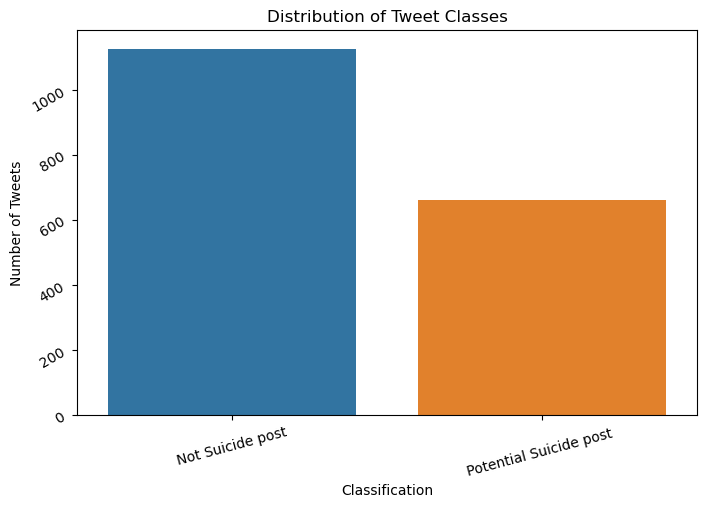

In [6]:
# Create a bar chart showing the class distribution

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Suicide")

plt.title("Distribution of Tweet Classes")
plt.xlabel("Classification")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=15)
plt.yticks(rotation=30)

plt.show()

## 6. Handle Missing Values

The `Tweet` column contains the text that the model will analyze.

Rows without tweet text cannot be used for text classification, so these rows will be removed from the dataset.

Only rows with missing values in the `Tweet` column will be removed.

In [7]:
# Display rows with missing tweets
df[df["Tweet"].isnull()]

,Tweet,Suicide
497,NaN,Potential Suicide post
1017,NaN,Not Suicide post


In [8]:
# Remove rows where the Tweet column is missing
df = df.dropna(subset=["Tweet"])

# Verify that no tweets are missing
print("Missing Tweets:", df["Tweet"].isnull().sum())

# Display updated dataset shape
print("New Dataset Shape:", df.shape)

Missing Tweets: 0
New Dataset Shape: (1785, 2)


## 7. Check for Duplicate Tweets

Duplicate tweets can cause data leakage into datasets if the same tweet appears in both the training and testing sets. If a duplicate tweet are in both, the model just remembers the answer instead of learning. The result: your test score looks very high, but the model will fail on truly new data.

We will identify and remove exact duplicate tweets.

In [9]:
# Count duplicate tweets
print("Number of duplicate tweets:", df["Tweet"].duplicated().sum())

Number of duplicate tweets: 8


In [10]:
# Display examples of duplicate tweets
df[df["Tweet"].duplicated(keep=False)].sort_values("Tweet").head(20)

,Tweet,Suicide
1040,@jessedonoe I mean.... my life is miserable so I guess light at the end of the tunnel,Potential Suicide post
1458,@jessedonoe I mean.... my life is miserable so I guess light at the end of the tunnel,Potential Suicide post
951,AFTER EFFECTS HAS FROZEN AND I DID NOT I REPEAT I DID NOT SAVE MY EDIT I WANT TO ACTUALLY FUCKING DIE .... IT TOOKâ¦ https://t.co/yif8DABTQm,Potential Suicide post
1173,AFTER EFFECTS HAS FROZEN AND I DID NOT I REPEAT I DID NOT SAVE MY EDIT I WANT TO ACTUALLY FUCKING DIE .... IT TOOKâ¦ https://t.co/yif8DABTQm,Potential Suicide post
223,Became as hot as the persistent days resting heavily on tired flowers,Potential Suicide post
432,Became as hot as the persistent days resting heavily on tired flowers,Potential Suicide post
662,I hate myself,Potential Suicide post
1362,I hate myself,Potential Suicide post
235,RT @MileyCyrus: Completely devestated by the fires affecting my community. I am one of the lucky ones. My animals and LOVE OF MY LIFE madeâ¦,Not Suicide post
749,RT @MileyCyrus: Completely devestated by the fires affecting my community. I am one of the lucky ones. My animals and LOVE OF MY LIFE madeâ¦,Not Suicide post


In [11]:
# Remove duplicate tweets
df = df.drop_duplicates(subset=["Tweet"])

# Verify that duplicates were removed
print("New Dataset Shape:", df.shape)
print("Remaining Duplicate Tweets:", df["Tweet"].duplicated().sum())

New Dataset Shape: (1777, 2)
Remaining Duplicate Tweets: 0


## 8. Clean and Encode the Target Variable

The target labels contain text values.

We will first remove any leading or trailing whitespace and then convert the categories into numerical values:

- `0` = Not Suicide Post
- `1` = Potential Suicide Post

Numerical labels allow the machine learning model to process the target variable.

In [12]:
# Remove leading and trailing spaces from the labels
df["Suicide"] = df["Suicide"].str.strip()

# Convert text labels to numerical labels
df["label"] = df["Suicide"].map({
    "Not Suicide post": 0,
    "Potential Suicide post": 1
})

# Display examples
df[["Tweet", "Suicide", "label"]].head(10)

,Tweet,Suicide,label
0,making some lunch,Not Suicide post,0
1,@Alexia You want his money.,Not Suicide post,0
2,@dizzyhrvy that crap took me forever to put together. iâm going to go sleep for DAYS,Potential Suicide post,1
3,@jnaylor #kiwitweets Hey Jer! Since when did you start twittering?,Not Suicide post,0
4,Trying out &quot;Delicious Library 2&quot; with mixed results The bar code thought I wanted to add a sport bra instead of a drill Cool app tho!,Not Suicide post,0
5,"@ValenValdez Oh, that's good to hear. But is it over already? Or you'll continue it after the Holy week?",Not Suicide post,0
6,@mcm180 u've got a list for fellow #hotties? You gonna have to share that one Amigo!,Not Suicide post,0
7,"@jakepaul @jamescharles @LoganPaul Just because shane made a Series on you Doesnt mean people take you seriously, yâ¦ https://t.co/D5rA0nua0U",Potential Suicide post,1
8,time for some warsaw beer garden chilling,Not Suicide post,0
9,I hate my life lmao I hope I die soon or sumn I'm too tired of everything,Potential Suicide post,1


In [13]:
# Check the number of examples in each numerical class
print("Label Counts:")
print(df["label"].value_counts())

# Check for labels that failed to map
print("\nMissing Labels:", df["label"].isnull().sum())

Label Counts:
label
0    1124
1     653
Name: count, dtype: int64

Missing Labels: 0


## 9. Examine Examples from Each Class

Before training the model, we can examine examples from each category.

This will help us understand the type of language and context represented in the dataset.

In [14]:
# Display random examples of Potential Suicide Posts
df[df["label"] == 1].sample(10, random_state=42)

,Tweet,Suicide,label
290,tired of waking up. tired of wanting to die. tired of everything.,Potential Suicide post,1
705,GOD FUCK IM A DUMB FUCKING IDIOT WHO CALLED OUT PERSONAL INSTEAD OF SICK GUESS WHOS GETTING THEIR THIRD REPRIMAND Sâ¦ https://t.co/r9W52o6LNY,Potential Suicide post,1
514,"RT @rikis_e: since we're talking abt him, hey uhh remember when YandereDev said intellectually disabled people deserve to die, played RapeLâ¦",Potential Suicide post,1
1144,all influencers want to be comedians and all comedians want to be dead.,Potential Suicide post,1
1196,its crazy cause i shut myself out on two ppl i been down w. soo long ð¯ and ik i love them to death and i would probâ¦,Potential Suicide post,1
1229,I hate myself so much,Potential Suicide post,1
769,work slave i really feel like my only purpose in life is to make a higher man money parents forcing me through college and i have too much on my plate i owe a lot of money i know this is the easy way out but i am really tired all of these issues are on top of dealing with tensions in america as well i want to rest,Potential Suicide post,1
421,I'm sick and tired of people putting so much energy into shitting on ships but they won't do the same to help a livâ¦ https://t.co/hyFuB3D04a,Potential Suicide post,1
271,Tired of kickin you bitches out the house ð bout ready to go to sleep and wake up to the same ting forever.,Potential Suicide post,1
697,"@slxmdunk,United Kingdom,@Pamaj what hapens if i dont want to be here anymore?",Potential Suicide post,1


In [15]:
# Display random examples of Not Suicide Posts
df[df["label"] == 0].sample(10, random_state=42)

,Tweet,Suicide,label
1732,RT @ebuka_akara: The best Stan Lee Cameo ever ððð https://t.co/leoQNCbXHG,Not Suicide post,0
1436,@MattKelland that Dalek is great,Not Suicide post,0
1192,"@jasongaunt Yeah, lots of potential. I think they've been working on their own iPhone app for months now How are you mate? Been a while!",Not Suicide post,0
216,@theshortestfuse that is so cool...good to hear...thanks for sharing!,Not Suicide post,0
1664,"@tikitosca New York, please",Not Suicide post,0
855,@effyobie STOP SPEAKING IN SUCH A SOPHISTICATED WAY PLEASE. it's hard for me to keep up!!,Not Suicide post,0
1305,"@MissSmashlee oh not alot, uni, working, same as just about everyone. handed in the first assignment in over a year on friday, was crazy",Not Suicide post,0
782,RT @joonswrlds: Jimin is so happy. I love him. #Jimin @BTS_twt https://t.co/e1IIA610tB,Not Suicide post,0
1777,"@SociallyCubed i miss IRC culture, Twitter is like the mainstream version, without the trout slapping",Not Suicide post,0
1514,@Mendelt Goodmorning dude! long time no see,Not Suicide post,0


## 10. Prepare Features and Target Variables

We will now separate the dataset into:

- `X`: The tweet text used as input to the model
- `y`: The numerical target label

The model will learn to predict `y` based on the text contained in `X`.

In [16]:
# X contains the tweet text
X = df["Tweet"]

# y contains the target labels
y = df["label"]

print("Number of Tweets:", len(X))
print("Number of Labels:", len(y))

Number of Tweets: 1777
Number of Labels: 1777


## 11. Split Data into Training and Testing Sets

The dataset will be divided into two groups:

- **Training data (80%)**: Used to train the machine learning model
- **Testing data (20%)**: Used to evaluate the model on tweets it has not seen before

The `stratify=y` parameter ensures that the proportion of each class remains similar in both datasets.

In [17]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display dataset sizes
print("Training Tweets:", len(X_train))
print("Testing Tweets:", len(X_test))

print("\nTraining Class Distribution:")
print(y_train.value_counts())

print("\nTesting Class Distribution:")
print(y_test.value_counts())

Training Tweets: 1421
Testing Tweets: 356

Training Class Distribution:
label
0    899
1    522
Name: count, dtype: int64

Testing Class Distribution:
label
0    225
1    131
Name: count, dtype: int64


## 12. Convert Text into Numerical Features Using TF-IDF

Machine learning models cannot directly process raw text.

TF-IDF (Term Frequency-Inverse Document Frequency) converts text into numerical features based on the importance of words within the dataset.

The vectorizer will use:

- Individual words (unigrams)
- Two-word combinations (bigrams)

This allows the model to learn both individual terms and short phrases.

The TF-IDF vectorizer will only be fitted on the training data to prevent data leakage.

In [18]:
# Create the TF-IDF vectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=10000,
    ngram_range=(1, 2)
)

## 13. Fit the TF-IDF Vectorizer

The vectorizer will learn the vocabulary from the training data.

The testing data will only be transformed using the vocabulary learned from the training data.

In [19]:
# Learn the vocabulary from the training data
# and transform the training tweets

X_train_tfidf = tfidf.fit_transform(X_train)

# Transform the testing tweets using the same vocabulary
X_test_tfidf = tfidf.transform(X_test)

# Display the resulting dimensions
print("Training TF-IDF Shape:", X_train_tfidf.shape)
print("Testing TF-IDF Shape:", X_test_tfidf.shape)

Training TF-IDF Shape: (1421, 10000)
Testing TF-IDF Shape: (356, 10000)


## 14. Train a Logistic Regression Classifier

Logistic Regression will be used as the first baseline classification model.

The model will learn patterns in the TF-IDF features and classify tweets into:

- `0` = Not Suicide Post
- `1` = Potential Suicide Post

In [20]:
# Create the Logistic Regression model

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
model.fit(X_train_tfidf, y_train)

print("Model training complete!")

Model training complete!


## 15. Generate Predictions

The trained model will now classify tweets from the testing dataset.

Because the testing dataset was not used during training, it provides an estimate of how the model performs on unseen data.

In [21]:
# Generate predictions for the testing data
y_pred = model.predict(X_test_tfidf)

# Display the first 20 predictions
print(y_pred[:20])

[1 0 0 0 0 0 0 1 0 1 1 0 0 1 0 0 0 1 1 0]


## 16. Evaluate Model Performance

The model will be evaluated using:

- Accuracy
- Precision
- Recall
- F1-score

For this project, recall for the `Potential Suicide Post` class is particularly important because it measures how many of the tweets labeled as potentially concerning were successfully identified by the model.

In [22]:
# Calculate evaluation metrics

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

# Display results
print("Model Performance")
print("-----------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Model Performance
-----------------
Accuracy : 0.9382
Precision: 0.9291
Recall   : 0.9008
F1 Score : 0.9147


## 17. Detailed Classification Report

The classification report provides precision, recall, F1-score, and support for each class.

This allows us to evaluate the model's performance separately for:

- Not Suicide Post
- Potential Suicide Post

In [23]:
# Display detailed classification metrics

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Not Suicide Post",
            "Potential Suicide Post"
        ]
    )
)

                        precision    recall  f1-score   support

      Not Suicide Post       0.94      0.96      0.95       225
Potential Suicide Post       0.93      0.90      0.91       131

              accuracy                           0.94       356
             macro avg       0.94      0.93      0.93       356
          weighted avg       0.94      0.94      0.94       356



## 18. Confusion Matrix

A confusion matrix shows where the model made correct and incorrect predictions.

The four possible outcomes are:

- True Negative: Correctly predicted Not Suicide Post
- True Positive: Correctly predicted Potential Suicide Post
- False Positive: Not Suicide Post incorrectly flagged
- False Negative: Potential Suicide Post incorrectly classified as Not Suicide Post

False negatives are particularly important to examine because they represent potentially concerning posts that the model failed to flag.

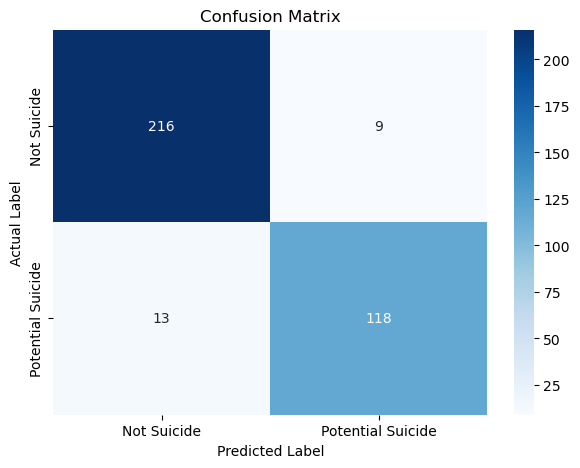

In [24]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Not Suicide",
        "Potential Suicide"
    ],
    yticklabels=[
        "Not Suicide",
        "Potential Suicide"
    ]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

## 19. Error Analysis

Analyzing incorrect predictions helps us understand where the model struggles.

We will examine:

- False negatives
- False positives

This can help identify areas where the model could potentially be improved.

In [25]:
# Create a dataframe containing the test tweets,
# actual labels, and predicted labels

results = pd.DataFrame({
    "Tweet": X_test,
    "Actual": y_test,
    "Predicted": y_pred
})

# Convert numerical labels back to readable text

results["Actual_Label"] = results["Actual"].map({
    0: "Not Suicide Post",
    1: "Potential Suicide Post"
})

results["Predicted_Label"] = results["Predicted"].map({
    0: "Not Suicide Post",
    1: "Potential Suicide Post"
})

results.head()

,Tweet,Actual,Predicted,Actual_Label,Predicted_Label
1413,@PoorBoyOnline Was no reason for you to get banned 2k not right..Ronnie stay banning folks that do nothing but tryâ¦ https://t.co/zijyqCpXoE,1,1,Potential Suicide Post,Potential Suicide Post
829,"@Overspill Well, can you link me to it anyway???",0,0,Not Suicide Post,Not Suicide Post
325,@Fortitia how's it cooking? looking forward to having a taste later.,0,0,Not Suicide Post,Not Suicide Post
54,he want to kill her.,0,0,Not Suicide Post,Not Suicide Post
1106,"interesting to note how twitter is like branding..the more you tweet, the more people follow - thanks for the follow Alister, Mark, Greg",0,0,Not Suicide Post,Not Suicide Post


## 20. False Negative Analysis

False negatives are tweets that were labeled as `Potential Suicide Post` but the model predicted `Not Suicide Post`.

These examples are particularly important because they represent potentially concerning posts that were not flagged by the model.

In [26]:
# Identify false negatives

false_negatives = results[
    (results["Actual"] == 1) &
    (results["Predicted"] == 0)
]

print("Number of False Negatives:", len(false_negatives))

# Display false negatives
false_negatives[
    ["Tweet", "Actual_Label", "Predicted_Label"]
]

Number of False Negatives: 13


,Tweet,Actual_Label,Predicted_Label
305,"RT @rosettalind55: @BrettCMajor1 I`m sick and tired of listening to @JustinTrudeau saying,""First and foremost ,we`re all here to work for Câ¦",Potential Suicide Post,Not Suicide Post
943,Sometimes youâll never know how bad you fucked up until one day you wake up with nothing,Potential Suicide Post,Not Suicide Post
1682,I swear it doesnât matter what time I go to sleep my body forever wakes up tired,Potential Suicide Post,Not Suicide Post
1158,RT @BijinChihiro: 11æ11æ¥ ð¹#BLACKCOVE ðð¬#Family of 80 #dolphins decimated-7 died from stress-48 captured #freedom forever lost-Defenseless #â¦,Potential Suicide Post,Not Suicide Post
1350,"@candyguy53,Tillsonburg, Ontario,@amvetsupport Ok.",Potential Suicide Post,Not Suicide Post
651,Dunno why my phones done me so dirty and made videos of me and my exâs Cos of face recognition with the backgroundâ¦ https://t.co/x6KfbmgBP9,Potential Suicide Post,Not Suicide Post
1159,Millwall v Blackburn travel purchased for live on Sky sports selection. Cant wait to go to the game with value!,Potential Suicide Post,Not Suicide Post
963,"RT @darkles_sparkle: @GameOfThrones ""My name is Arya Stark. I want you to know that. The last thing youâre ever going to see is a Stark smiâ¦",Potential Suicide Post,Not Suicide Post
151,My heart is so crushed.,Potential Suicide Post,Not Suicide Post
391,Gene has been acting a bit odd lately. When I told him about Leper wanting to jump out of the tree to join The Supeâ¦ https://t.co/jqjOwpBQ1X,Potential Suicide Post,Not Suicide Post


## 21. False Positive Analysis

False positives are tweets that were labeled as `Not Suicide Post` but the model predicted `Potential Suicide Post`.

These examples are useful for understanding what language may cause the model to incorrectly flag a tweet.

In [27]:
# Identify false positives

false_positives = results[
    (results["Actual"] == 0) &
    (results["Predicted"] == 1)
]

print("Number of False Positives:", len(false_positives))

# Display false positives
false_positives[
    ["Tweet", "Actual_Label", "Predicted_Label"]
]

Number of False Positives: 9


,Tweet,Actual_Label,Predicted_Label
141,@tmotsenbocker @TheAcademic @judahandthelion Take it all back was so fun https://t.co/iewkzKosB8,Not Suicide Post,Potential Suicide Post
1653,@xxandip uh oh i take it someone cant spell your name? im a katie and hate it when people put katy x,Not Suicide Post,Potential Suicide Post
1370,"RT @JoshYugen: @EntrataLorna @maymayentrata07 Hi tita @EntrataLorna now I know why she is the most humble and most genuine, even though itâ¦",Not Suicide Post,Potential Suicide Post
1549,@Thetoffeemen1 @SimonMidi9790 @RonaldKoeman @Everton sure just get that homework done while celebrating that poin https://t.co/oi7X3ZTLGy,Not Suicide Post,Potential Suicide Post
1645,RT @VibeFeeIings: Your hardest times often lead to the greatest moments of your life. Keep the faith. It will all be worth in the end.,Not Suicide Post,Potential Suicide Post
255,"RT @0mysky: If you find someone that makes you happy, enjoy it... life is not fair nor give many opportunities... https://t.co/dCBwDeQVH8",Not Suicide Post,Potential Suicide Post
1116,Appreciate and be grateful for every given moment and live your life with love + joy #EnjoyLife #EnjoyFriends https://t.co/1Qwj7Jtq8N,Not Suicide Post,Potential Suicide Post
748,RT @MrEdTrain: #NeverForget who keeps you &amp; your family safe &amp; free ðºð¸ @USMC @USARMY @USNAVY @USAF @USCG https://t.co/z21HWgPaYn,Not Suicide Post,Potential Suicide Post
1559,I just want it to be healthy.,Not Suicide Post,Potential Suicide Post


## 22. Prediction Probability

Logistic Regression can provide a probability score representing how strongly the model associates a tweet with the `Potential Suicide Post` class.

This score represents the model's estimated class probability based on patterns learned from the training dataset. It should not be interpreted as a real-world probability that an individual is suicidal.

In [28]:
# Generate probability scores for the Potential Suicide Post class

y_prob = model.predict_proba(X_test_tfidf)[:, 1]

# Add probabilities to the results dataframe
results["Potential_Suicide_Probability"] = y_prob

# Display highest probability predictions
results.sort_values(
    "Potential_Suicide_Probability",
    ascending=False
)[
    [
        "Tweet",
        "Actual_Label",
        "Predicted_Label",
        "Potential_Suicide_Probability"
    ]
].head(20)

,Tweet,Actual_Label,Predicted_Label,Potential_Suicide_Probability
762,"@MNTNTOP,,fuck this shit i want to be dead so i dont have to be here anymore https://t.co/1M6PZKhT9v",Potential Suicide Post,Potential Suicide Post,0.980053
20,"@sadegsi,ger/rus/eng,I want to die so much, I dont want to be here anymore",Potential Suicide Post,Potential Suicide Post,0.973507
744,wow i want to die! somebody fucking kill me! PLEASE! https://t.co/oyySkOcTE0,Potential Suicide Post,Potential Suicide Post,0.960004
400,"@AbigailBrooke29,With Jake :),RT @yxrx_x: I desperately and whole heartedly dont want to be here anymore.",Potential Suicide Post,Potential Suicide Post,0.955198
775,my life has no purpose i am broke lonely and miserable i am so my life is a sack of shit my family legitimately hate me i am poor i have some friends but dont hear from them unless i get in touch first i have been single for almost a decade generally i am ok with being single but depression grinds my world to a halt doctors dont help me nobody around me seems to understand this has gone on for 30 years i am tired cant do it any more i just want to lay down and die quietly all i want in life is to disappear,Potential Suicide Post,Potential Suicide Post,0.942863
1634,I am a thousand percent done with âprotocolsâ and everything else. I am tired of explaining and giving further backâ¦ https://t.co/4I6B8qUF8f,Potential Suicide Post,Potential Suicide Post,0.941467
139,"@308Olsen,Blaine, MN,I dont want to be here anymore.",Potential Suicide Post,Potential Suicide Post,0.935696
1538,I dont want to be here anymore,Potential Suicide Post,Potential Suicide Post,0.935696
1229,I hate myself so much,Potential Suicide Post,Potential Suicide Post,0.934774
1242,@WarcraftDevs can u do something about demo holy fucking SHIT its been months without ANYTHING done do u not realiâ¦ https://t.co/g4m6reGxUg,Potential Suicide Post,Potential Suicide Post,0.934320


## 23. Analyze Uncertain Predictions

Tweets with probabilities close to 0.50 are the examples where the model is least confident.

Examining these tweets can help identify areas where the model may need additional training data or more advanced NLP techniques.

In [29]:
# Calculate how far each prediction is from 0.50

results["Uncertainty"] = abs(
    results["Potential_Suicide_Probability"] - 0.5
)

# Display the least confident predictions

results.sort_values(
    "Uncertainty"
)[
    [
        "Tweet",
        "Actual_Label",
        "Predicted_Label",
        "Potential_Suicide_Probability"
    ]
].head(20)

,Tweet,Actual_Label,Predicted_Label,Potential_Suicide_Probability
391,Gene has been acting a bit odd lately. When I told him about Leper wanting to jump out of the tree to join The Supeâ¦ https://t.co/jqjOwpBQ1X,Potential Suicide Post,Not Suicide Post,0.499226
516,"RT @mjs03093641: TWEETS are the real life, awkward conversation starters between strangers.",Potential Suicide Post,Potential Suicide Post,0.502952
1720,seems like instead of me hoping i ll live past 27 i am praying i ll live past 20 i have really all but given up right now each and every day i think about disappearing from the world more and more as if its becoming an actual option,Potential Suicide Post,Potential Suicide Post,0.504583
859,"Offense or Defense , passive or violent. I cut my wrist and my heartbeat is silent",Potential Suicide Post,Potential Suicide Post,0.508517
557,Isn't it sad that after seeing a firetruck in front of a building my first thought was to look up in case someone wâ¦ https://t.co/Ro8dAw5j0N,Potential Suicide Post,Potential Suicide Post,0.508958
1370,"RT @JoshYugen: @EntrataLorna @maymayentrata07 Hi tita @EntrataLorna now I know why she is the most humble and most genuine, even though itâ¦",Not Suicide Post,Potential Suicide Post,0.512774
1660,i am a failure a loser i m a waste of life and i want it to be over we can finally close this pathetic story the only concern i have is debt i cant leave my family with that,Potential Suicide Post,Not Suicide Post,0.485798
748,RT @MrEdTrain: #NeverForget who keeps you &amp; your family safe &amp; free ðºð¸ @USMC @USARMY @USNAVY @USAF @USCG https://t.co/z21HWgPaYn,Not Suicide Post,Potential Suicide Post,0.514472
812,i think it was my lack of saying anything at all that was pretty stupid when i met harry. i was acting all cool andâ¦ https://t.co/lpdqwGeI8J,Potential Suicide Post,Potential Suicide Post,0.515124
1109,@ravogd my weird dreams are a part of my life now and make me who i am xxxxxxxxx,Not Suicide Post,Not Suicide Post,0.483151


## 24. Create a Function for New Tweets

The following function allows a user to enter a new tweet and receive a model prediction.

The model will return:

- The original tweet
- The predicted class
- The model's estimated probability for the Potential Suicide Post class

The output should be interpreted as a machine learning classification result and not as a diagnosis or definitive assessment of an individual's mental health.

In [30]:
def predict_tweet(tweet):
    """
    Classify a new tweet using the trained TF-IDF
    vectorizer and Logistic Regression model.
    """
    
    # Convert the new tweet into TF-IDF features
    tweet_tfidf = tfidf.transform([tweet])
    
    # Generate the prediction
    prediction = model.predict(tweet_tfidf)[0]
    
    # Generate the probability of Potential Suicide Post
    probability = model.predict_proba(tweet_tfidf)[0][1]
    
    # Convert numerical prediction to readable label
    if prediction == 1:
        label = "Potential Suicide Post"
    else:
        label = "Not Suicide Post"
    
    # Display results
    print("Tweet:")
    print(tweet)
    print()
    
    print("Prediction:", label)
    print(
        "Potential Suicide Probability:",
        round(probability * 100, 2),
        "%"
    )
    
    return prediction, probability

## 25. Test the Model on a New Tweet

The model can now be tested with a new tweet that was not part of the original dataset.

In [31]:
# Test the model with a new example

predict_tweet(
    "I don't know how much longer I can keep doing this"
)

Tweet:
I don't know how much longer I can keep doing this

Prediction: Not Suicide Post
Potential Suicide Probability: 31.79 %


(0, 0.31793978471020906)

## 26. Test Multiple New Tweets

The following examples demonstrate how the model can classify multiple tweets.

In [32]:
# Create a list of example tweets

new_tweets = [
    "I had a great day with my family today",
    "I don't know how much longer I can keep doing this",
    "I am excited about my plans for the weekend",
    "I feel like nobody would notice if I disappeared"
]

# Run predictions for each tweet

for tweet in new_tweets:
    print("=" * 70)
    predict_tweet(tweet)
    print()

Tweet:
I had a great day with my family today

Prediction: Not Suicide Post
Potential Suicide Probability: 9.4 %

Tweet:
I don't know how much longer I can keep doing this

Prediction: Not Suicide Post
Potential Suicide Probability: 31.79 %

Tweet:
I am excited about my plans for the weekend

Prediction: Not Suicide Post
Potential Suicide Probability: 19.84 %

Tweet:
I feel like nobody would notice if I disappeared

Prediction: Potential Suicide Post
Potential Suicide Probability: 59.02 %



# Project Conclusion

This project developed a Natural Language Processing classification model capable of distinguishing between tweets labeled as `Not Suicide Post` and `Potential Suicide Post`.

## Methodology

The project followed these steps:

1. Loaded and explored the Twitter dataset
2. Examined class distribution
3. Removed missing tweets
4. Removed duplicate tweets
5. Cleaned and encoded target labels
6. Split the data into training and testing sets
7. Converted tweet text into TF-IDF features
8. Trained a Logistic Regression classifier
9. Evaluated model performance using accuracy, precision, recall, and F1-score
10. Visualized results using a confusion matrix
11. Analyzed false positives and false negatives
12. Examined model prediction probabilities
13. Created a function for classifying new tweets

## Model Performance

The Logistic Regression model achieved approximately:

- **94% Accuracy**
- **93% Precision** for Potential Suicide Posts
- **90% Recall** for Potential Suicide Posts
- **91% F1-score** for Potential Suicide Posts

## Key Takeaways

The results demonstrate that traditional NLP techniques such as TF-IDF combined with Logistic Regression can perform well on a binary text classification problem.

However, the model has limitations. The dataset contains a relatively small number of labeled tweets, and the model may not generalize to all social media platforms, writing styles, languages, or real-world situations.

Future improvements could include:

- Comparing Logistic Regression with Linear Support Vector Machines
- Hyperparameter tuning
- Testing different TF-IDF configurations
- Using word embeddings
- Exploring transformer-based NLP models
- Increasing the size and diversity of the training dataset
- Improving model calibration
- Further analyzing false negatives and false positives

This project should be considered a machine learning classification exercise and not a diagnostic or clinical tool. Any real-world use involving potential suicide risk would require appropriate safeguards, human oversight, and careful consideration of privacy and ethical concerns.